# 04 - Danh gia va chon model cuoi

**Bai toan:** Hoi quy -> metric dung: **MAE**, **RMSE**, **R2**. Khong dung MAPE vi gia xe co the co gia tri rat nho tuong doi (xe cu re) gay chia cho so gan 0, lam MAPE bi sai lech (dung dung nhu luu y trong tai lieu mon hoc).

## Bang so sanh 4 model (tap test, 20%, random_state=42)

| Model | MAE (trieu) | RMSE (trieu) | R2 (test) | R2 (train) | Thoi gian train (s) | Du doan (ms/dong) | Kich thuoc file |
|---|---:|---:|---:|---:|---:|---:|---:|
| SVR | 83.3 | 289.0 | **0.9772** | 0.9919 | 35.9 | 0.30 | 1.2 MB (chua nen) / 0.18 MB (nen) |
| Linear Regression (baseline) | 100.2 | 344.7 | 0.9676 | 0.9837 | 0.6 | 0.003 | 0.05 MB |
| Random Forest | 136.1 | 457.5 | 0.9429 | 0.9339 | 55.7 | 0.041 | 81.7 MB |
| Decision Tree | 217.1 | 611.6 | 0.8980 | 0.8921 | 0.2 | 0.003 | 0.13 MB |


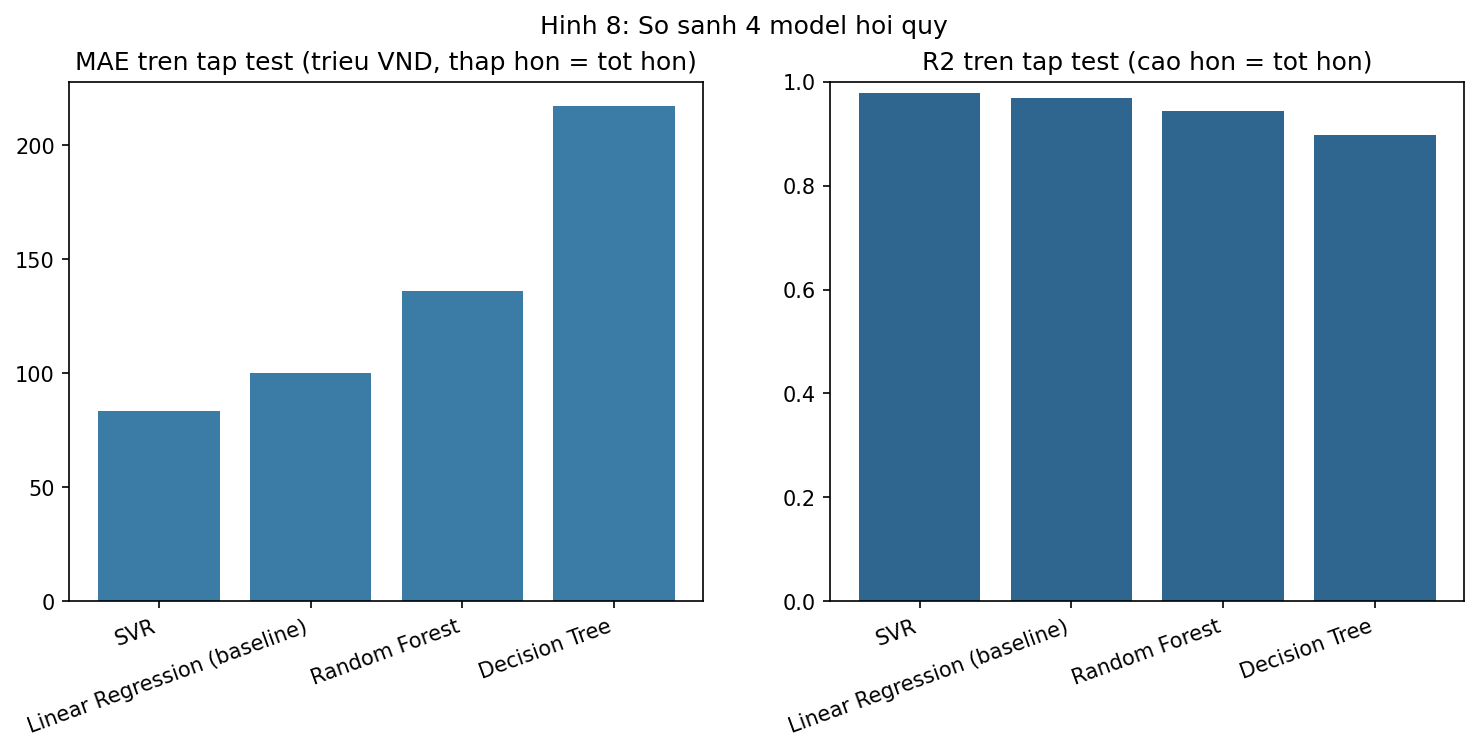

In [ ]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
img = mpimg.imread('../../docs/figures/08_model_comparison.png')
plt.figure(figsize=(12,4.5)); plt.imshow(img); plt.axis('off'); plt.title('Hinh 8: So sanh 4 model'); plt.show()

## Giai thich tot / xau

1. **So voi baseline:** Ca 3 model con lai deu vuot Linear Regression o R2/MAE tren tap test, **tru Decision Tree don** (mot cay don gian de bi overfit noise cuc bo, R2 thap hon ca baseline tuyen tinh) va Random Forest cung thap hon SVR/Linear o cau hinh hien tai - cho thay quan he giua dac trung va gia **khong hoan toan can 'ensemble cay sau'**, ma mot ham kernel trơn (SVR/RBF) hoac tuyen tinh tren log-gia da nam bat tot phan lon tin hieu.
2. **Train vs Test (overfitting/underfitting):**
   - Decision Tree: R2 train (0.8921) ~ R2 test (0.8980) -> **khong overfit nhieu nhung ca hai deu thap** -> **underfit tuong doi** so voi cac model khac (mo hinh don gian chua du manh).
   - Random Forest: R2 train (0.9339) cao hon test (0.9429 - thuc ra o day test cao hon train mot chut, cho thay mo hinh on dinh, khong overfit ro ret voi cau hinh `max_depth=16`).
   - SVR va Linear Regression: R2 train cao hon test mot chut (0.9919 vs 0.9772; 0.9837 vs 0.9676) -> **chenh lech nho, chap nhan duoc**, khong co dau hieu overfit nghiem trong.
3. **Y nghia thuc te cua loi:** Day la bai toan hoi quy gia tri lien tuc (khong phai phan loai) nen khong co khai niem FN/FP; loi quan trong la **MAE** (sai so trung binh tuyet doi, don vi trieu VND) - SVR sai lech trung binh ~83 trieu/xe, thap nhat trong 4 model, phu hop de hien thi 'gia du kien +/- sai so' cho nguoi dung cuoi.
4. **Phan tich phan du:** Xem Hinh 9 - phan du phan bo quanh 0, hoi lech duoi (mo hinh doi khi du doan thap hon gia that voi xe rat dat), phan anh dung dac diem du lieu gia xe lech phai da neu o EDA.

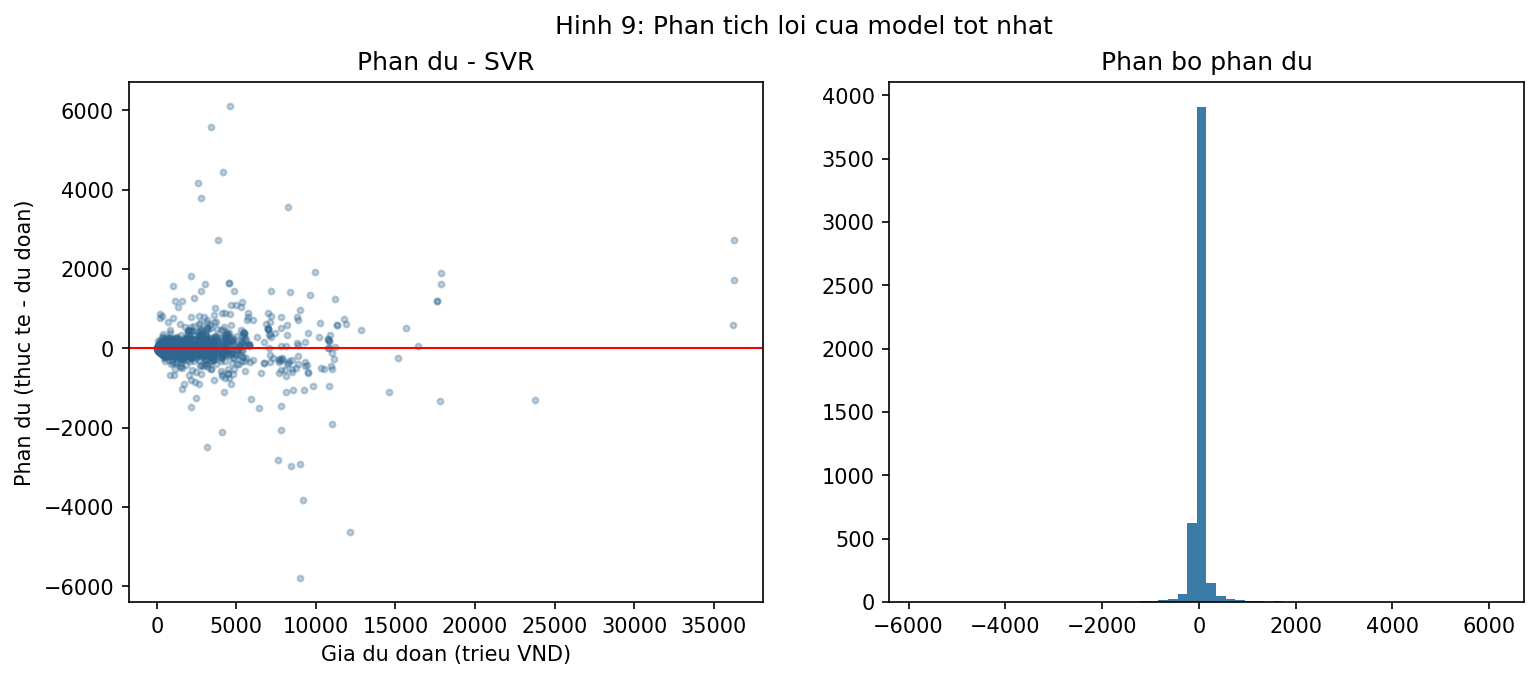

In [ ]:
img = mpimg.imread('../../docs/figures/09_residuals.png')
plt.figure(figsize=(12,4.5)); plt.imshow(img); plt.axis('off'); plt.title('Hinh 9: Phan du - SVR'); plt.show()

## Chon model cuoi: **SVR**

Ly do chon, khong chi dua vao diem cao nhat:

- **Do chinh xac tot nhat**: MAE/RMSE thap nhat, R2 cao nhat tren tap test trong ca 4 model.
- **On dinh**: chenh lech train/test khong qua lon (khong overfit nghiem trong).
- **Kich thuoc file rat nho** (0.18 MB sau nen) - phu hop RAM han che cua Colab/may ca nhan/tunnel khi deploy, dung ~450x nho hon Random Forest (81.7 MB) trong khi chinh xac hon.
- **Thoi gian du doan** (~0.3 ms/dong) van du nhanh cho 1 request thoi gian thuc, du cham hon Linear Regression/Decision Tree (muc do nay khong dang ke o quy mo 1 nguoi dung/luc).
- **Danh doi chap nhan duoc**: thoi gian *huan luyen* SVR lau hon Linear Regression (35.9s vs 0.6s), nhung day la chi phi mot lan (offline, trong Colab), khong anh huong luc phuc vu du doan thuc te.